# Resources

[1. Tutorial on time delay cacluation](https://stackoverflow.com/questions/4967453/time-delay-estimation-between-two-audio-signals)

In [17]:
from utils.imports import *

# 1. Define the path to your extracted ffmpeg bin folder
# (Change this to wherever you actually saved it)
ffmpeg_bin_path = r"C:\ffmpeg\ffmpeg-8.1.1-full_build-shared\bin"
# 2. Add it to the Windows PATH for this specific Python session
os.environ["PATH"] += os.pathsep + ffmpeg_bin_path
# 3. Tell Python where to look for DLLs (Required for Python 3.8+ on Windows)
if hasattr(os, 'add_dll_directory'):
    os.add_dll_directory(ffmpeg_bin_path)
# 4. NOW you can import torchaudio safely

# Utils

### 2.2.b,c)

In [59]:
@staticmethod
def audio_simulator(input, source_loc:tuple, mic_locs:list|tuple):
    """
    Def:
    :params input
    :params tuple of floats source_loc: Holding the cartesian coordinates of the source; 
    :params list of tuples mic_locs: Holding the cartesian coordinates of multiple microphones. If all the microphones share the same location then the argument becomes a tuple

    Return: waveforms (visualiazation) and time_delays
    """

    def _time_delay_calculation(mic=mic_locs, source=source_loc, common_loc=False):
        for index, locations in enumerate(mic):
            relative_time_delays.append(np.round((np.sqrt( (source[0]-locations[0])**2 + (source[1]-locations[1])**2)/c)*sr))

        # 2. Locate the furthest situated microphone by time_delay: the more samples, the furthest
        furtherst = max(relative_time_delays)
        for relative_time in relative_time_delays:
            delay = furtherst-relative_time
            waveforms.append(input[int(delay):])

    c:int=340*100
    sr:int = 48000
    relative_time_delays:list = []
    waveforms:list = []

    if isinstance(mic_locs, tuple):
        _time_delay_calculation(True)
    elif isinstance(mic_locs, list):
        _time_delay_calculation()
    
    
    return relative_time_delays, waveforms

Initial signal shape torch.Size([2, 396226])
Preprocessed signal shape torch.Size([396226])


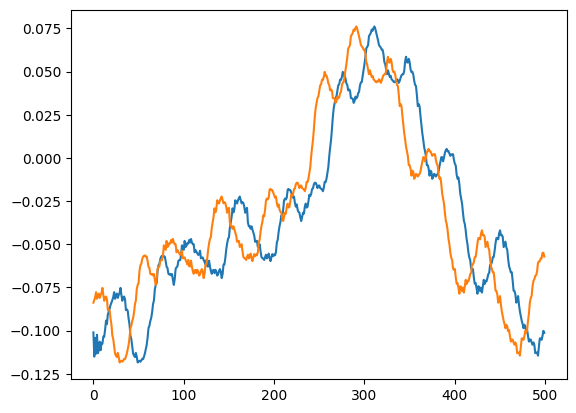

In [61]:
# 1. Loading the signal (e.g., mp3 track)
waveform, sample_rate = torchaudio.load(r'utils\assignment_2_dataset\train\curlew.mp3')
# 2. Averaging out the signal's channels - THIS IS A PREPROCESSING STEP w
mono_waveform = torch.mean(waveform, dim=0)



# Informative print
print("Initial signal shape {}\nPreprocessed signal shape {}".format(waveform.shape, mono_waveform.shape))


relative_time_delays, waveforms = audio_simulator(input=mono_waveform, source_loc=(200, 100), mic_locs=[(-8, 0),(8, 0)])

PLT.plot(waveforms[0][:500])
PLT.plot(waveforms[1][:500])

